# **Lab 3: Introduction to Programming in PySpark RDD**

Lecturer: `Sirasit Lochanachit`


Course: `06026213 Big Data Systems`

Term: `02/2025`

Lab materials prepared by `Duangkamon Phobsungnoen (TA) - 2024`

ตัวอย่าง Code ในไฟล์นี้เป็นการติดตั้ง Spark แบบ local mode ใน virtual machine (หากรันบน Google Golab) หรือในเครื่องตัวเอง (หากรันบน VS Code หรือ IDE อื่นๆ)
ที่เชื่อมต่อกับ Jupyter Notebook

การรันคำสั่งบน Jupyter Notebook เหมือนเป็นการสร้าง Spark
Application แต่สามารถรันทีละคำสั่งได้

# 1. Spark Application, SparkSession, and SparkContext

> Step 1: เริ่มต้นด้วยการติดตั้ง PySpark ผ่าน pip

In [ ]:
!pip install pyspark

PySpark คือ Python API สำหรับ Apache Spark.
- It enables you to perform real-time, large-scale data **processing** in a distributed environment using Python.
- It also provides a PySpark shell for interactively **analyzing** your data.

PySpark supports all of Spark’s features such as Spark SQL, DataFrames, Structured Streaming, Machine Learning (MLlib) and Spark Core.

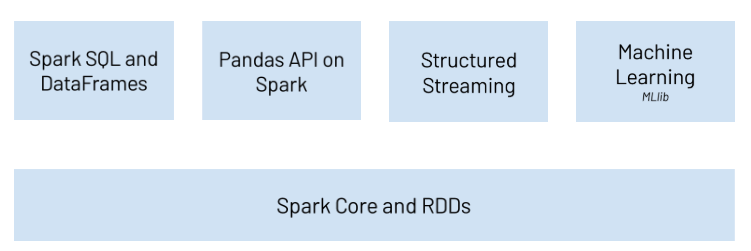

> Step 2: สร้าง Spark Application ด้วย SparkSession

- SparkSession คือ Class ที่เป็นจุดศูนย์รวมของทุก function ที่มีใน Spark
- ใช้ SparkSession.builder ในการสร้าง SparkSession object
- หลังจาก builder สามารถระบุ option ต่างๆที่ต้องการตั้งค่า เช่น
  - appName("ชื่อแอพ") คือการตั้งชื่อแอพ
  - config("spark.some.config.option", "some-value")
  - getOrCreate() จะไปดึง SparkSession instance ที่มีชื่อนี้อยู่แล้ว แต่หากไม่มีก็จะสร้างแอพหรือ SparkSession instance ขึ้นมาใหม่

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
ss =

> ตรวจสอบ Version ของ Spark

In [ ]:
print(f"Spark Version: {ss.version}")

แสดง local attributes ทั้งหมด (function, class, object) ที่เก็บอยู่ใน instance/object

In [ ]:
ss.__dict__
# vars(ss)

แสดง attributes ทั้งหมด (function, class, object) รวมถึงที่ inherit มาจาก class/superclass/parent ที่เก็บอยู่ใน instance/object
- จะเห็นว่ามี sparkContext object อยู่

In [ ]:
dir(ss)

**SparkContext** คือ object หลักใน Apache Spark ที่ทำหน้าที่เป็นตัวเชื่อมต่อระหว่าง Spark application และ cluster ที่ใช้ในการประมวลผลข้อมูล โดย SparkContext จะคอยจัดการการติดต่อกับ cluster และควบคุมการกระจายงานให้กับโหนดต่างๆ ใน cluster ซึ่งช่วยให้สามารถทำงานแบบ parallel ได้อย่างมีประสิทธิภาพ

In [ ]:
ss.sparkContext.appName

> Step x: การหยุดการทำงานของ SparkSession
- เนื่องจาก SparkSession เป็น Session เหมือน connection ที่เราเปิดค้างไว้ ซึ่งมันจะต้องมีการจองทรัพยากรค้างไว้ และกิน JVM memory ซึ่งตามหลักก็ควรจะปิด Session อันที่ไม่ได้ใช้งานแล้ว
- ข้างใน SparkSession ก็จะมี SparkContext ซึ่งจะใช้ทรัพยากรของ cluster และมันจะเอาไปใช้กับ task อื่นๆไม่ได้ รวมถึง task ที่ไม่ได้ใช้ Spark Application ซึ่งก็คือตัวทรัพยากรถูกกันไว้
- SparkContext ควรจะมีแค่ 1 instance เท่านั้นต่อ 1 JVM/Session หากจะสร้าง SparkContext ใหม่ใน Session เดิมจะต้อง stop ของเก่าก่อน
- หรือหากต้องการเริ่ม Spark ใหม่ภายในโปรแกรม/Session เดียวกัน สามารถหยุด SparkContext ที่มีอยู่เดิมก่อน โดยใช้คำสั่ง stop()

In [ ]:
ss.stop()

# 2. การสร้าง Parallelized Collection

**Objective**

*   เข้าใจการสร้าง RDD จากชุดข้อมูลใน Python โดยใช้คำสั่ง sparkContext.parallelize
*   ใช้ฟังก์ชัน reduce ในการคำนวณผลรวมของตัวเลขใน RDD
*   ศึกษาการแบ่งข้อมูลเป็นพาร์ติชันและการตั้งค่าจำนวนพาร์ติชันใน Spark


**RDD (Resilient Distributed Dataset)** คือโครงสร้างข้อมูลหลักใน Spark ซึ่งรองรับการประมวลผลแบบกระจายและทนทานต่อข้อผิดพลาด (fault-tolerant)

**RDD (Resilient Distributed Dataset) ใน Spark รองรับ operation function 2 ประเภท คือ Transformations และ Actions**


-   **Transformations** คือการสร้างชุดข้อมูลใหม่จากชุดข้อมูลเดิม (RDD ใหม่จาก RDD เดิม) โดยจะมีการประมวลผลทีละ partition แต่ผลลัพธ์จะไม่ได้รับการคำนวณทันที แต่จะบันทึกเฉพาะการ transform (transformation) ที่ได้ทำไปแล้ว
    - เช่น ฟังก์ชัน map ที่จะรับข้อมูลแต่ละตัวในแต่ละ partition ในชุดข้อมูล RDD เดิม และ transform ให้เป็นค่าผลลัพธ์ใหม่ในรูปแบบ RDD ใหม่
    - map() เป็นการส่ง function ไปให้ transform บนแต่ละ partition
    - Transformation function จะไม่ประมวลผลจนกว่าจะมี action function
-   **Actions** คือการคำนวณข้อมูลที่ได้แปลงไปแล้วในแต่ละ partition และส่งผลลัพธ์สุดท้ายหลังการรวมกลับมาที่โปรแกรมหลัก (driver program)
    - เช่น ฟังก์ชัน reduce ที่จะคำนวณค่าแต่ละค่าใน partition โดยทำทีละคู่ เช่น lambda x,y: x+y คือ รวมกันทีละคู่
    - จากนั้นนำผลลัพธ์ของแต่ละ partition มารวมกัน เพื่อทำการรวมค่าทั้งหมดใน RDD (reduce) โดยใช้ฟังก์ชันการรวม (aggregation) และส่งผลลัพธ์สุดท้ายกลับไปยังโปรแกรมหลัก (driver)





## Example 1: Basic RDD

1. ตัวอย่าง list ของข้อมูลแบบง่าย

In [ ]:
data = [1,2,3,4,5]

2. ลองสร้าง RDD จาก list ของข้อมูล

ในขั้นตอนนี้ จะทำการสร้าง RDD จากลิสต์ [1, 2, 3, 4, 5] โดยใช้คำสั่ง `parallelize()` ซึ่งทำการกระจายข้อมูลออกเป็น partition หลายๆอัน เพื่อสามารถแจกจ่ายไปยัง Data Node ต่างๆ

In [ ]:
rdd =

ตรวจสอบจำนวน Partition โดย default

ตรวจสอบประเภทของตัวแปร/object

In [ ]:
rdd

collect() ใช้ในการดึงข้อมูลจาก RDD และนำมาแสดงผลในรูปแบบของลิสต์ใน Python

3. Transform ข้อมูลด้วย map function
- map() ใช้สำหรับ transform ข้อมูลใน RDD โดยจะทำการ transform ก็ต่อเมื่อมี action function เท่านั้น จึงเปรียบเสมือนการเตรียม setup ไว้ก่อน และสร้าง RDD ใหม่ขึ้นมา

In [ ]:
rdd_multi = rdd.map(lambda x: x * 2)

จะได้ RDD ใหม่ขึ้นมา

In [ ]:
rdd_multi

4. Execute action function เพื่อให้ประมวลผล
- collect() ใช้ในการดึงข้อมูลจาก RDD และนำมาแสดงผลในรูปแบบของลิสต์ใน Python

In [ ]:
rdd_multi.collect()

เทียบกับ RDD เดิม

In [ ]:
rdd.collect()

## Example 2: Basic RDD with Partitions

1. สุ่ม list ของ integer

In [ ]:
import random
data2 = random.sample(range(100),10)

In [ ]:
data2

2. ในครั้งนี้ จะทำการสร้าง RDD โดยกำหนดจำนวน Partition ที่จะแบ่งข้อมูล (ในกรณีนี้ เราจะใช้ 3 Partition)

In [ ]:
rdd2 = ss.sparkContext.parallelize(data2, 3)

ดูจำนวน Partition

ดูข้อมูลทั้งหมดในทุก partition

In [ ]:
rdd2.collect()

3. หากต้องการดูข้อมูลในแต่ละ partition สามารถใช้คำสั่ง glom()
- เป็น Transformation function เหมือน map() และทำการสร้าง RDD ใหม่ขึ้นมา

In [ ]:
partitions = rdd2.glom()
partitions

4. Execute action function เพื่อให้ประมวลผล
- collect() ใช้ในการดึงข้อมูลจาก RDD และนำมาแสดงผลในรูปแบบของลิสต์ใน Python

In [ ]:
partitions.collect()

- take(n) เป็น action function ที่นำข้อมูล n ตัวแรกมาแสดงผล

In [ ]:
partitions.take(2)

In [ ]:
rdd2.take(2)

In [ ]:
rdd2.take()

ใช้ map() ในการ transform ข้อมูล RDD และสร้าง RDD ใหม่ขึ้นมา

ใช้ map ในการ transform ข้อมูล RDD และ run take(n) action function เพื่อประมวลผลในลักษณะ parallel processing (แต่ละ partition ประมวลผลคู่ขนานกันไป) แล้วค่อยแสดง/รวบรวมผลลัพธ์

## Example 3: คำนวณผลรวมข้อมูล

1. คำนวณผลรวมของข้อมูลทั้งหมดใน RDD โดยใช้ฟังก์ชัน reduce ซึ่งจะช่วยให้สามารถรวมค่าต่างๆ จาก RDD ได้อย่างมีประสิทธิภาพ
2. ฟังก์ชัน reduce() จะรับ funtion ที่ทำการคำนวณระหว่างสองค่า (ในกรณีนี้ เราจะใช้การบวกเลข) และจะประมวลผลข้อมูลทั้งหมดใน RDD ในลักษณะคู่ขนานกันไป (parallel processing)
3. ได้ผลลัพธ์จาก reduce()


คำนวณผลคูณข้อมูล

หากใช้ Partitions ที่เป็น list ของ list จะได้ผลลัพธ์เป็นการนำ list ข้างในมาทำ operation + กัน ซึ่งก็คือการนำ list มาต่อกัน

In [ ]:
partitions.reduce(lambda a, b: a + b) # list + list + list

# 3. อ่านไฟล์ข้อมูลจาก External Datasets

ในการใช้ PySpark กับชุดข้อมูลภายนอก (External Datasets) เราสามารถสร้าง RDD (Resilient Distributed Datasets) จากแหล่งเก็บข้อมูลต่างๆ เช่น local filesystem, HDFS, Cassandra, HBase, Amazon S3 ฯลฯ ซึ่ง Spark รองรับไฟล์หลายประเภท เช่น Text files, SequenceFiles, และ Hadoop Input Format ในรูปแบบอื่นๆ

---

## Example: อ่านไฟล์ txt

**โจทย์:** สมมติว่าเรามีไฟล์ข้อความที่ชื่อ example_data.txt ซึ่งมีข้อมูลเป็นข้อความต่างๆ โดยแต่ละบรรทัดมีข้อความที่แตกต่างกัน

เป้าหมายคือต้องการหาผลรวมของจำนวนตัวอักษร (ถ้ามีช่องว่างจะต้องลบช่องว่างออกก่อน) ในทุกบรรทัดของไฟล์นี้ โดยใช้ PySpark ในการประมวลผลข้อมูล

**Step 1: สร้างไฟล์ example_data.txt**

In [ ]:
with open("/content/example_data.txt", "w") as f:
  f.write("Data Science Year 3 \n")
  f.write("Merry Xmas \n")
  f.write("Happy New Year 2025 \n")

ตรวจสอบว่าไฟล์ example_data.txt มีอยู่ในโฟลเดอร์ /content หรือไม่

In [ ]:
!ls /content/
# or !ls

หากไฟล์สร้างสำเร็จ จะเห็น example_data.txt ในรายชื่อไฟล์ที่แสดงออกมา


In [ ]:
!ls

ตรวจสอบ current working directory

In [ ]:
!pwd

**Step 2: อ่านไฟล์ example_data.txt**

ใช้ฟังก์ชัน textFile() เพื่ออ่านข้อมูลจากไฟล์และสร้าง RDD

จากนั้นใช้ collect() เพื่อแสดงข้อมูลทั้งหมดจากไฟล์ในแต่ละบรรทัด

In [ ]:
rddFile =

rddFile.collect()

ใน rddFile เป็น RDD ที่ประกอบไปด้วยข้อความแต่ละบรรทัดจากไฟล์ example_data.txt

**Step 3: นับจำนวนตัวอักษรของแต่ละบรรทัด**

ใช้ฟังก์ชัน map() เพื่อคำนวณจำนวนตัวอักษรในแต่ละบรรทัด

จากนั้นใช้ collect() แสดงผลลัพธ์เป็นจำนวนตัวอักษรในแต่ละบรรทัด

In [ ]:
lengths_data = rddFile.map(lambda line: len(line))
lengths_data.collect()

ผลลัพธ์ที่แสดงออกมาจะได้เป็นจำนวนตัวอักษรของแต่ล่ะบรรทัด โดยมีการนับช่องว่างเข้าไปด้วย **ดังนั้นเราสามารถลบช่องว่างโดยใช้ replace()**

In [ ]:
lengths_data = rddFile.map(lambda line: len(line.replace(" ", "")))
lengths_data.collect()

**Step 4: หาผลรวมของจำนวนตัวอักษรทั้งหมด**

หลังจากที่นับจำนวนตัวอักษรในแต่ละบรรทัดแล้ว

ขั้นตอนถัดไปคือการหาผลรวมของตัวอักษรทั้งหมดในไฟล์ โดยใช้ฟังก์ชัน reduce() ในการหาผลรวม

In [ ]:
total_length = lengths_data.reduce(lambda a,b: a+b)
print(f"ผลรวมของจำนวนตัวอักษรทั้งหมดในไฟล์: {total_length}")

# Exercise: อ่านไฟล์ยอดขายสินค้าในรูปแบบ csv และทำการรวมยอดขายแบ่งตามร้าน

## Step 1: สร้างข้อมูล sales_data.csv

In [ ]:
import csv

# ข้อมูลที่จะเขียนลงในไฟล์ CSV
data = [
    {'store_id': 1, 'product_id': 'A123', 'product_name': 'Apple', 'quantity_sold': 50, 'sale_date': '2024-11-01'},
    {'store_id': 2, 'product_id': 'B456', 'product_name': 'Banana', 'quantity_sold': 30, 'sale_date': '2024-11-02'},
    {'store_id': 1, 'product_id': 'A123', 'product_name': 'Apple', 'quantity_sold': 20, 'sale_date': '2024-11-03'},
    {'store_id': 3, 'product_id': 'C789', 'product_name': 'Carrot', 'quantity_sold': 40, 'sale_date': '2024-11-01'},
    {'store_id': 2, 'product_id': 'B456', 'product_name': 'Banana', 'quantity_sold': 10, 'sale_date': '2024-11-03'},
    {'store_id': 3, 'product_id': 'C789', 'product_name': 'Carrot', 'quantity_sold': 15, 'sale_date': '2024-11-02'}
]

# กำหนดชื่อคอลัมน์สำหรับไฟล์ CSV
header = ['store_id', 'product_id', 'product_name', 'quantity_sold', 'sale_date']

# เขียนข้อมูลลงในไฟล์ CSV
filename = '/content/sales_data.csv'

with open(filename, mode='w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=header)

    # เขียนหัวข้อ (header) ลงในไฟล์
    writer.writeheader()

    # เขียนข้อมูลลงในไฟล์
    writer.writerows(data)

# คืนค่าชื่อไฟล์ filename เพื่อให้สามารถตรวจสอบได้ว่าไฟล์ถูกสร้างสำเร็จ
print(f"File {filename} has been created.")


In [ ]:
import pandas as pd

# DataFrame of store_id,product_id,product_name,quantity_sold,sale_date
df = pd.DataFrame(data)
df

## Step 2: อ่านข้อมูลจากไฟล์และสร้าง RDD

In [ ]:
sales_data =

## Step 3: แสดงข้อมูลทั้งหมด (collect)

## Step 4: การแปลงข้อมูลให้เป็นโครงสร้างแบบ Tuple (Key, Value)

ใช้ฟังก์ชัน map เพื่อแปลงแต่ละบรรทัดใน csv ให้เป็น Tuple ของ (store_id, (product_id, quantity_sold)) เพื่อที่จะรวมยอดขายตามแต่ละสาขา

ใช้ filter() ในการคัดเลือก/กรองข้อมูลออกมา ซึ่งจะได้ RDD ใหม่ (เป็น transformation function)


In [ ]:
header = sales_data.first() # ข้ามแถว header
sales_rdd = sales_data.filter(lambda line: line != header)  # กรองข้อมูลเหลือเฉพาะ data

In [ ]:
# ประมวลผล RDD: แยกแต่ละแถวด้วย , และทำการ map ข้อมูลเป็น tuple
sales_rdd = sales_rdd.map(lambda line: line.split(","))
sales_rdd = sales_rdd.map(lambda fields: (int(fields[0]), (fields[1], int(fields[3]))))

collect() เพื่อแสดงข้อมูลทั้งหมด

In [ ]:
sales_rdd.collect()

## Step 5: Filter ข้อมูลเฉพาะจำนวน product ที่ขาย (quantity_sold)

หากต้องการกรองเฉพาะรายการที่มี quantity_sold มากกว่า 20 ชิ้น สามารถใช้ filter เพื่อกรองข้อมูลที่ตรงกับเงื่อนไขนี้

In [ ]:
filtered_sales = sales_rdd.filter(lambda x: x[1][1] > 20)

filtered_sales.collect()

## Step 6: การนับจำนวนข้อมูลทั้งหมดที่ผ่านการ filter (count)

ใช้ count เพื่อหาจำนวนของข้อมูลที่ตรงกับเงื่อนไขที่กำหนด

In [ ]:
print(f"Number of Sales > 20: {filtered_sales.count()} product(s)")

## Step 7: การเรียงข้อมูล (SortByKey)

In [ ]:
sales_rdd.sortByKey().collect()

จากคำตอบจะเห็นได้ว่ามีการเรียงลำดับตามค่า store_id

**แล้วจะรู้ได้ไงว่า Key() คือ store_id ?**

TLDR; Tuple เก็บเป็น (key, value)

ก่อนที่จะใช้ sortByKey() โครงสร้างของข้อมูลใน sales_rdd จะเป็น tuple ที่มีรูปแบบดังนี้

`(store_id, (product_id, quantity_sold))`

*   Key: คือ store_id (ค่าในตำแหน่งที่ 0 ของ tuple)
*   Value: คือ (product_id, quantity_sold) (ค่าในตำแหน่งที่ 1 ของ tuple)



sortBy() สามารถใส่ function ได้

In [ ]:
sales_rdd.sortBy(lambda x: x[1][1], ascending=False).collect()

## Step 8: การดึงข้อมูล n รายการแรก (Take)

ใช้ฟังก์ชัน take(n) เพื่อดึงข้อมูลที่ต้องการจากชุดข้อมูลที่ผ่านการ transform หรือ filter

In [ ]:
sorted_sales = sales_rdd.sortByKey()
get_sales = sorted_sales.take(3)
print(f"Get first 3 Sales: {get_sales}")

## Step 9: การจับกลุ่มยอดขายแบ่งตามร้าน (groupByKey)

In [ ]:
sales_rdd.collect()

In [ ]:
sales_grouped_rdd = sales_rdd.groupByKey()
sales_grouped_rdd.collect()

In [ ]:
sales_grouped_rdd.mapValues(list).collect()

In [ ]:
sales_grouped_rdd.map(lambda x : (x[0], list(x[1]))).collect()

## Step 10: การรวมยอดขายแบ่งตามร้าน (ReduceByKey)

เราจะใช้ฟังก์ชัน reduceByKey เพื่อรวมยอดขายของแต่ละสินค้าในแต่ละสาขา เช่น หากในสาขามีการขายสินค้าเดียวกันหลายครั้ง เราจะรวมยอดขายทั้งหมด

In [ ]:
sales_rdd.collect()

pyspark.RDD.mapValues

Pass each value in the key-value pair RDD through a map function without changing the keys; this also retains the original RDD’s partitioning.

In [ ]:
sales_rdd.mapValues(lambda x: x[1]).collect()

In [ ]:
total_sales_per_store = sales_rdd.mapValues(lambda x: x[1]).reduceByKey(lambda a, b: ???)

total_sales_per_store.collect()

---